# EN3160 Assignment 01
## Intensity Transformations and Neighborhood Filtering

**Name:** Rahman MFA        
**Index Number:** 230507R           
**GitHub:** https://github.com/Abdul-Rahman-bme/EN3160-Image-processing-and-Machine-Vision

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
IMAGE_DIR = Path("images")
OUTPUT_DIR = Path("outputs")

OUTPUT_DIR.mkdir(exist_ok=True)

# Question 1 — Piecewise Intensity Transformation

A piecewise-linear intensity transformation maps each input grayscale intensity
to an output intensity using a set of user-defined breakpoints. Linear
interpolation is used between successive breakpoints. The breakpoint locations
control which intensity ranges are stretched or compressed and therefore
control the contrast of the resulting image.

In [3]:
img_q1 = cv.imread(str(IMAGE_DIR / "q1_portrait.png"), cv.IMREAD_GRAYSCALE)

if img_q1 is None:
    raise FileNotFoundError("Q1 image could not be loaded.")

print("Image shape:", img_q1.shape)
print("Data type:", img_q1.dtype)
print("Intensity range:", img_q1.min(), "to", img_q1.max())

Image shape: (451, 401)
Data type: uint8
Intensity range: 0 to 253


In [4]:
def intensity_transform(im, breakpoints):
    
    bp = np.asarray(breakpoints, dtype=np.float32)

    # Basic checks
    if bp.ndim != 2 or bp.shape[1] != 2:
        raise ValueError("breakpoints must have shape (N, 2)")

    x = bp[:, 0]
    y = bp[:, 1]

    if not np.all(np.diff(x) > 0):
        raise ValueError("Input breakpoint values must be strictly increasing.")

    output = np.zeros_like(im, dtype=np.float32)
    im_float = im.astype(np.float32)

    # Apply each linear segment
    for i in range(len(bp) - 1):
        x0, y0 = bp[i]
        x1, y1 = bp[i + 1]

        if i == len(bp) - 2:
            mask = (im_float >= x0) & (im_float <= x1)
        else:
            mask = (im_float >= x0) & (im_float < x1)

        slope = (y1 - y0) / (x1 - x0)

        output[mask] = y0 + slope * (im_float[mask] - x0)

    return np.clip(np.round(output), 0, 255).astype(np.uint8)

In [5]:
breakpoints_example = np.array([
    [0,   0],
    [50,  50],
    [100, 150],
    [150, 255],
    [255, 255]
], dtype=np.float32)

img_q1_example = intensity_transform(img_q1, breakpoints_example)

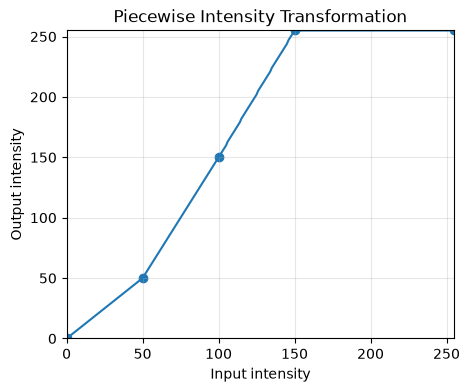

In [6]:
input_levels = np.arange(256, dtype=np.uint8)

mapped_levels = intensity_transform(
    input_levels,
    breakpoints_example
)

plt.figure(figsize=(5, 4))

plt.plot(input_levels, mapped_levels)
plt.scatter(
    breakpoints_example[:, 0],
    breakpoints_example[:, 1]
)

plt.xlim(0, 255)
plt.ylim(0, 255)

plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Piecewise Intensity Transformation")
plt.grid(alpha=0.3)

plt.show()

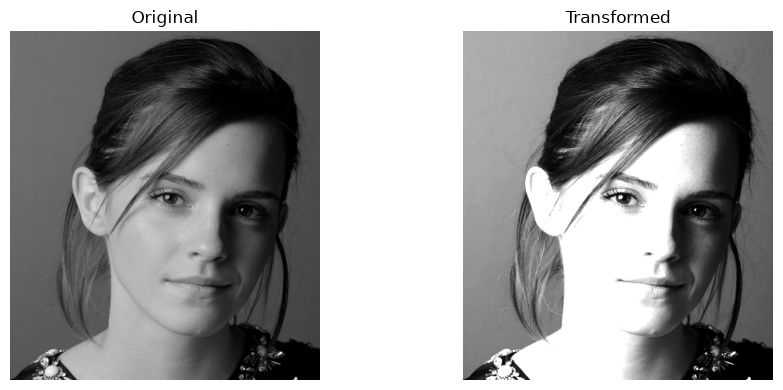

In [7]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img_q1, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_q1_example, cmap="gray", vmin=0, vmax=255)
plt.title("Transformed")
plt.axis("off")

plt.tight_layout()
plt.show()


In [9]:
breakpoints_1 = np.array([
    [0,   0],
    [50,  35],
    [100, 110],
    [160, 210],
    [220, 245],
    [255, 255]
], dtype=np.float32)

breakpoints_2 = np.array([
    [0,   0],
    [40,  25],
    [90,  80],
    [140, 175],
    [190, 230],
    [255, 255]
], dtype=np.float32)

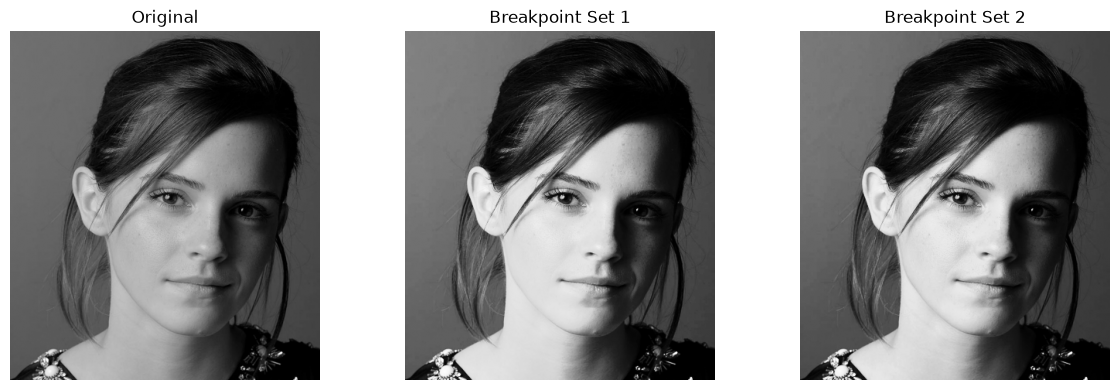

In [10]:
img_bp1 = intensity_transform(img_q1, breakpoints_1)
img_bp2 = intensity_transform(img_q1, breakpoints_2)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_q1, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_bp1, cmap="gray", vmin=0, vmax=255)
plt.title("Breakpoint Set 1")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_bp2, cmap="gray", vmin=0, vmax=255)
plt.title("Breakpoint Set 2")
plt.axis("off")

plt.tight_layout()
plt.show()

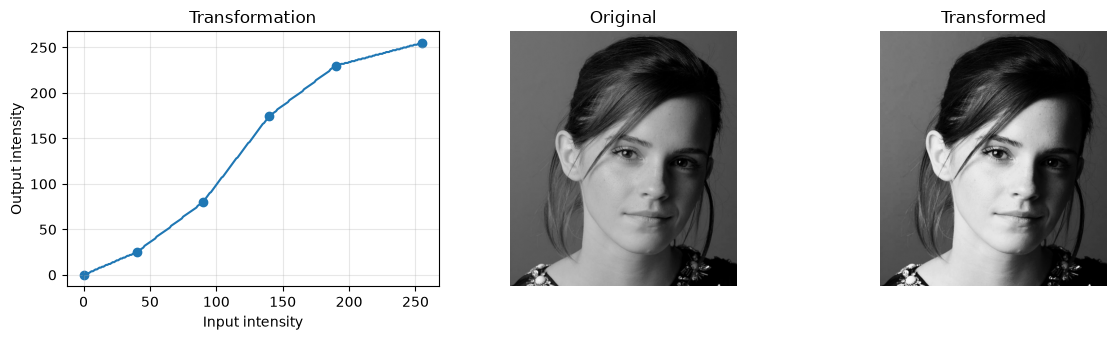

In [11]:
best_breakpoints = breakpoints_2   # replace after experimentation
best_img = intensity_transform(img_q1, best_breakpoints)

levels = np.arange(256, dtype=np.uint8)
mapped = intensity_transform(levels, best_breakpoints)

plt.figure(figsize=(12, 3.5))

plt.subplot(1, 3, 1)
plt.plot(levels, mapped)
plt.scatter(best_breakpoints[:, 0], best_breakpoints[:, 1])
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Transformation")
plt.grid(alpha=0.3)

plt.subplot(1, 3, 2)
plt.imshow(img_q1, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(best_img, cmap="gray", vmin=0, vmax=255)
plt.title("Transformed")
plt.axis("off")

plt.tight_layout()
plt.show()